<a href="https://colab.research.google.com/github/NMNayan57/Newcolab-file/blob/main/Dataset_paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Maternal Health Risk Dataset - Complete Analysis for Data in Brief Paper
# ========================================================================

# Cell 1: Install Required Libraries
!pip install pandas numpy matplotlib seaborn plotly scikit-learn xgboost shap kaleido


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 9.9 MB/s eta 0:00:00


In [2]:

# Cell 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import xgboost as xgb

# SHAP for model interpretability
import shap

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [3]:

# Cell 3: Load and Basic Data Exploration
# Upload your CSV file to Colab first
df = pd.read_csv('Mathernal_Risk.csv')

print("=== DATASET OVERVIEW ===")
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {len(df)}")
print(f"Total Features: {len(df.columns)}")
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\n=== FIRST 5 ROWS ===")
display(df.head())

print("\n=== DATASET INFO ===")
df.info()

print("\n=== MISSING VALUES CHECK ===")
missing_values = df.isnull().sum()
print(missing_values)
if missing_values.sum() == 0:
    print("✅ No missing values found!")


=== DATASET OVERVIEW ===
Dataset Shape: (6103, 11)
Total Records: 6103
Total Features: 11

Column Names:
1. Patient ID
2. Name
3. Age
4. Body Temperature(F) 
5. Heart rate(bpm)
6. Systolic Blood Pressure(mm Hg)
7. Diastolic Blood Pressure(mm Hg)
8. BMI(kg/m 2)
9. Blood Glucose(HbA1c)
10. Blood Glucose(Fasting hour-mg/dl)
11. Status

=== FIRST 5 ROWS ===


,Patient ID,Name,Age,Body Temperature(F),Heart rate(bpm),Systolic Blood Pressure(mm Hg),Diastolic Blood Pressure(mm Hg),BMI(kg/m 2),Blood Glucose(HbA1c),Blood Glucose(Fasting hour-mg/dl),Status
0,101,Bhavana,20,97.5,91,161,100,24.9,41,5.8,high risk
1,102,Mithila,45,97.7,99,99,94,22.1,36,5.7,high risk
2,103,Phoolan,29,98.6,84,129,87,19.0,42,6.4,mid risk
3,104,Joyonti,26,99.5,135,161,101,23.7,46,4.5,high risk
4,105,Vana,38,102.5,51,106,91,18.8,38,4.3,high risk



=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6103 entries, 0 to 6102
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Patient ID                         6103 non-null   int64  
 1   Name                               6103 non-null   object 
 2   Age                                6103 non-null   int64  
 3   Body Temperature(F)                6103 non-null   float64
 4   Heart rate(bpm)                    6103 non-null   int64  
 5   Systolic Blood Pressure(mm Hg)     6103 non-null   int64  
 6   Diastolic Blood Pressure(mm Hg)    6103 non-null   int64  
 7   BMI(kg/m 2)                        6103 non-null   float64
 8   Blood Glucose(HbA1c)               6103 non-null   int64  
 9   Blood Glucose(Fasting hour-mg/dl)  6103 non-null   float64
 10  Status                             6103 non-null   object 
dtypes: float64(3), int64(6), object(2)

In [4]:
# Cell 4: Data Cleaning and Feature Engineering
# Clean column names
df.columns = ['Patient_ID', 'Name', 'Age', 'Body_Temperature', 'Heart_Rate',
              'Systolic_BP', 'Diastolic_BP', 'BMI', 'Blood_Glucose_HbA1c',
              'Blood_Glucose_Fasting', 'Risk_Level']

# Remove unnecessary columns for analysis
df_analysis = df.drop(['Patient_ID', 'Name'], axis=1)

print("=== CLEANED DATASET ===")
print(f"Shape after cleaning: {df_analysis.shape}")
display(df_analysis.head())


=== CLEANED DATASET ===
Shape after cleaning: (6103, 9)


,Age,Body_Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,BMI,Blood_Glucose_HbA1c,Blood_Glucose_Fasting,Risk_Level
0,20,97.5,91,161,100,24.9,41,5.8,high risk
1,45,97.7,99,99,94,22.1,36,5.7,high risk
2,29,98.6,84,129,87,19.0,42,6.4,mid risk
3,26,99.5,135,161,101,23.7,46,4.5,high risk
4,38,102.5,51,106,91,18.8,38,4.3,high risk


In [5]:


# Cell 5: Basic Statistical Summary
print("=== STATISTICAL SUMMARY ===")
display(df_analysis.describe())

# Custom statistics table for the paper
numerical_cols = df_analysis.select_dtypes(include=[np.number]).columns
stats_summary = pd.DataFrame({
    'Feature': numerical_cols,
    'Min': [df_analysis[col].min() for col in numerical_cols],
    'Max': [df_analysis[col].max() for col in numerical_cols],
    'Mean': [round(df_analysis[col].mean(), 2) for col in numerical_cols],
    'Std': [round(df_analysis[col].std(), 2) for col in numerical_cols],
    'Median': [df_analysis[col].median() for col in numerical_cols]
})

print("\n=== DETAILED STATISTICS TABLE FOR PAPER ===")
display(stats_summary)


=== STATISTICAL SUMMARY ===


,Age,Body_Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,BMI,Blood_Glucose_HbA1c,Blood_Glucose_Fasting
count,6103.000000,6103.000000,6103.000000,6103.000000,6103.000000,6103.000000,6103.000000,6103.000000
mean,26.425037,98.665574,86.100770,129.218253,87.257578,21.435581,37.904473,5.504752
std,6.390205,1.590983,22.627587,17.234217,7.793099,2.157060,4.400272,0.905327
min,15.000000,39.600000,45.000000,90.000000,9.000000,14.900000,30.000000,3.500000
25%,22.000000,98.600000,72.000000,120.000000,82.000000,19.600000,34.000000,4.800000
50%,25.000000,98.600000,80.000000,128.000000,87.000000,21.300000,38.000000,5.700000
75%,30.000000,98.800000,91.000000,141.000000,92.000000,23.100000,41.000000,6.000000
max,250.000000,104.000000,150.000000,169.000000,142.000000,27.900000,50.000000,8.900000



=== DETAILED STATISTICS TABLE FOR PAPER ===


,Feature,Min,Max,Mean,Std,Median
0,Age,15.0,250.0,26.43,6.39,25.0
1,Body_Temperature,39.6,104.0,98.67,1.59,98.6
2,Heart_Rate,45.0,150.0,86.10,22.63,80.0
3,Systolic_BP,90.0,169.0,129.22,17.23,128.0
4,Diastolic_BP,9.0,142.0,87.26,7.79,87.0
5,BMI,14.9,27.9,21.44,2.16,21.3
6,Blood_Glucose_HbA1c,30.0,50.0,37.90,4.40,38.0
7,Blood_Glucose_Fasting,3.5,8.9,5.50,0.91,5.7


=== TARGET VARIABLE ANALYSIS ===
Risk Level Distribution:
high risk: 2059 (33.74%)
mid risk: 2043 (33.48%)
low risk: 2001 (32.79%)


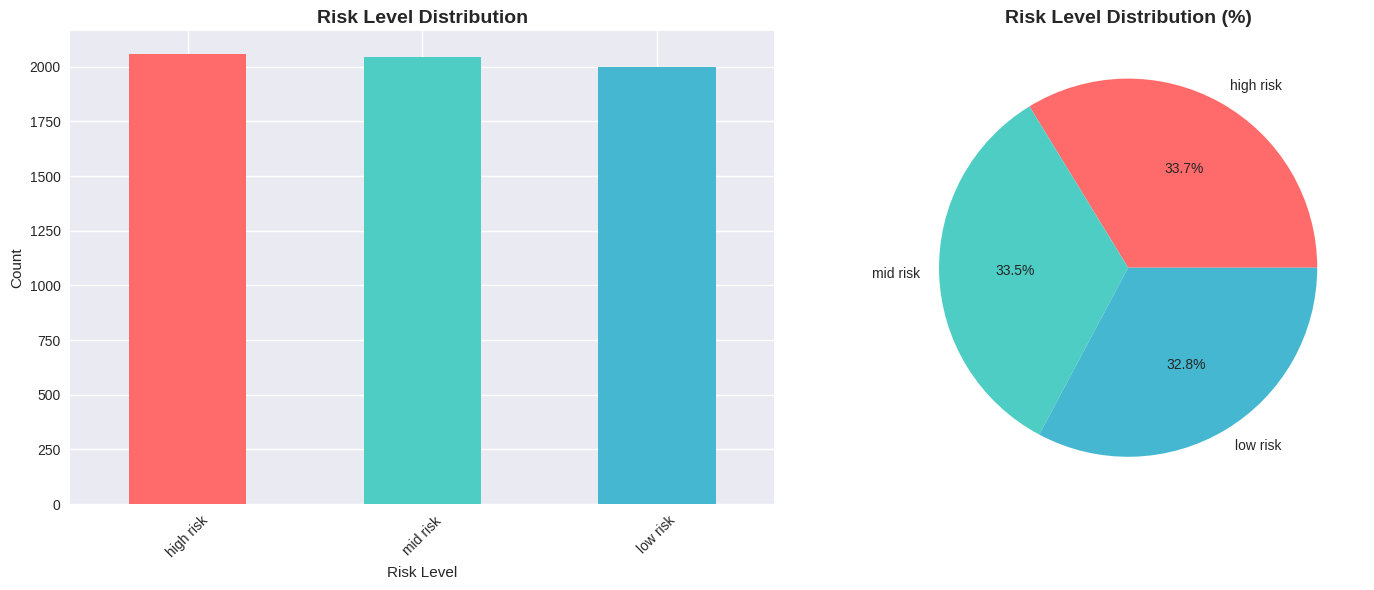

In [6]:
# Cell 6: Target Variable Analysis
print("=== TARGET VARIABLE ANALYSIS ===")
risk_counts = df_analysis['Risk_Level'].value_counts()
risk_percentages = df_analysis['Risk_Level'].value_counts(normalize=True) * 100

print("Risk Level Distribution:")
for level in risk_counts.index:
    count = risk_counts[level]
    percentage = risk_percentages[level]
    print(f"{level}: {count} ({percentage:.2f}%)")

# Visualization 1: Class Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar plot
risk_counts.plot(kind='bar', ax=ax1, color=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax1.set_title('Risk Level Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Risk Level')
ax1.set_ylabel('Count')
ax1.tick_params(axis='x', rotation=45)

# Pie chart
ax2.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',
        colors=['#ff6b6b', '#4ecdc4', '#45b7d1'])
ax2.set_title('Risk Level Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

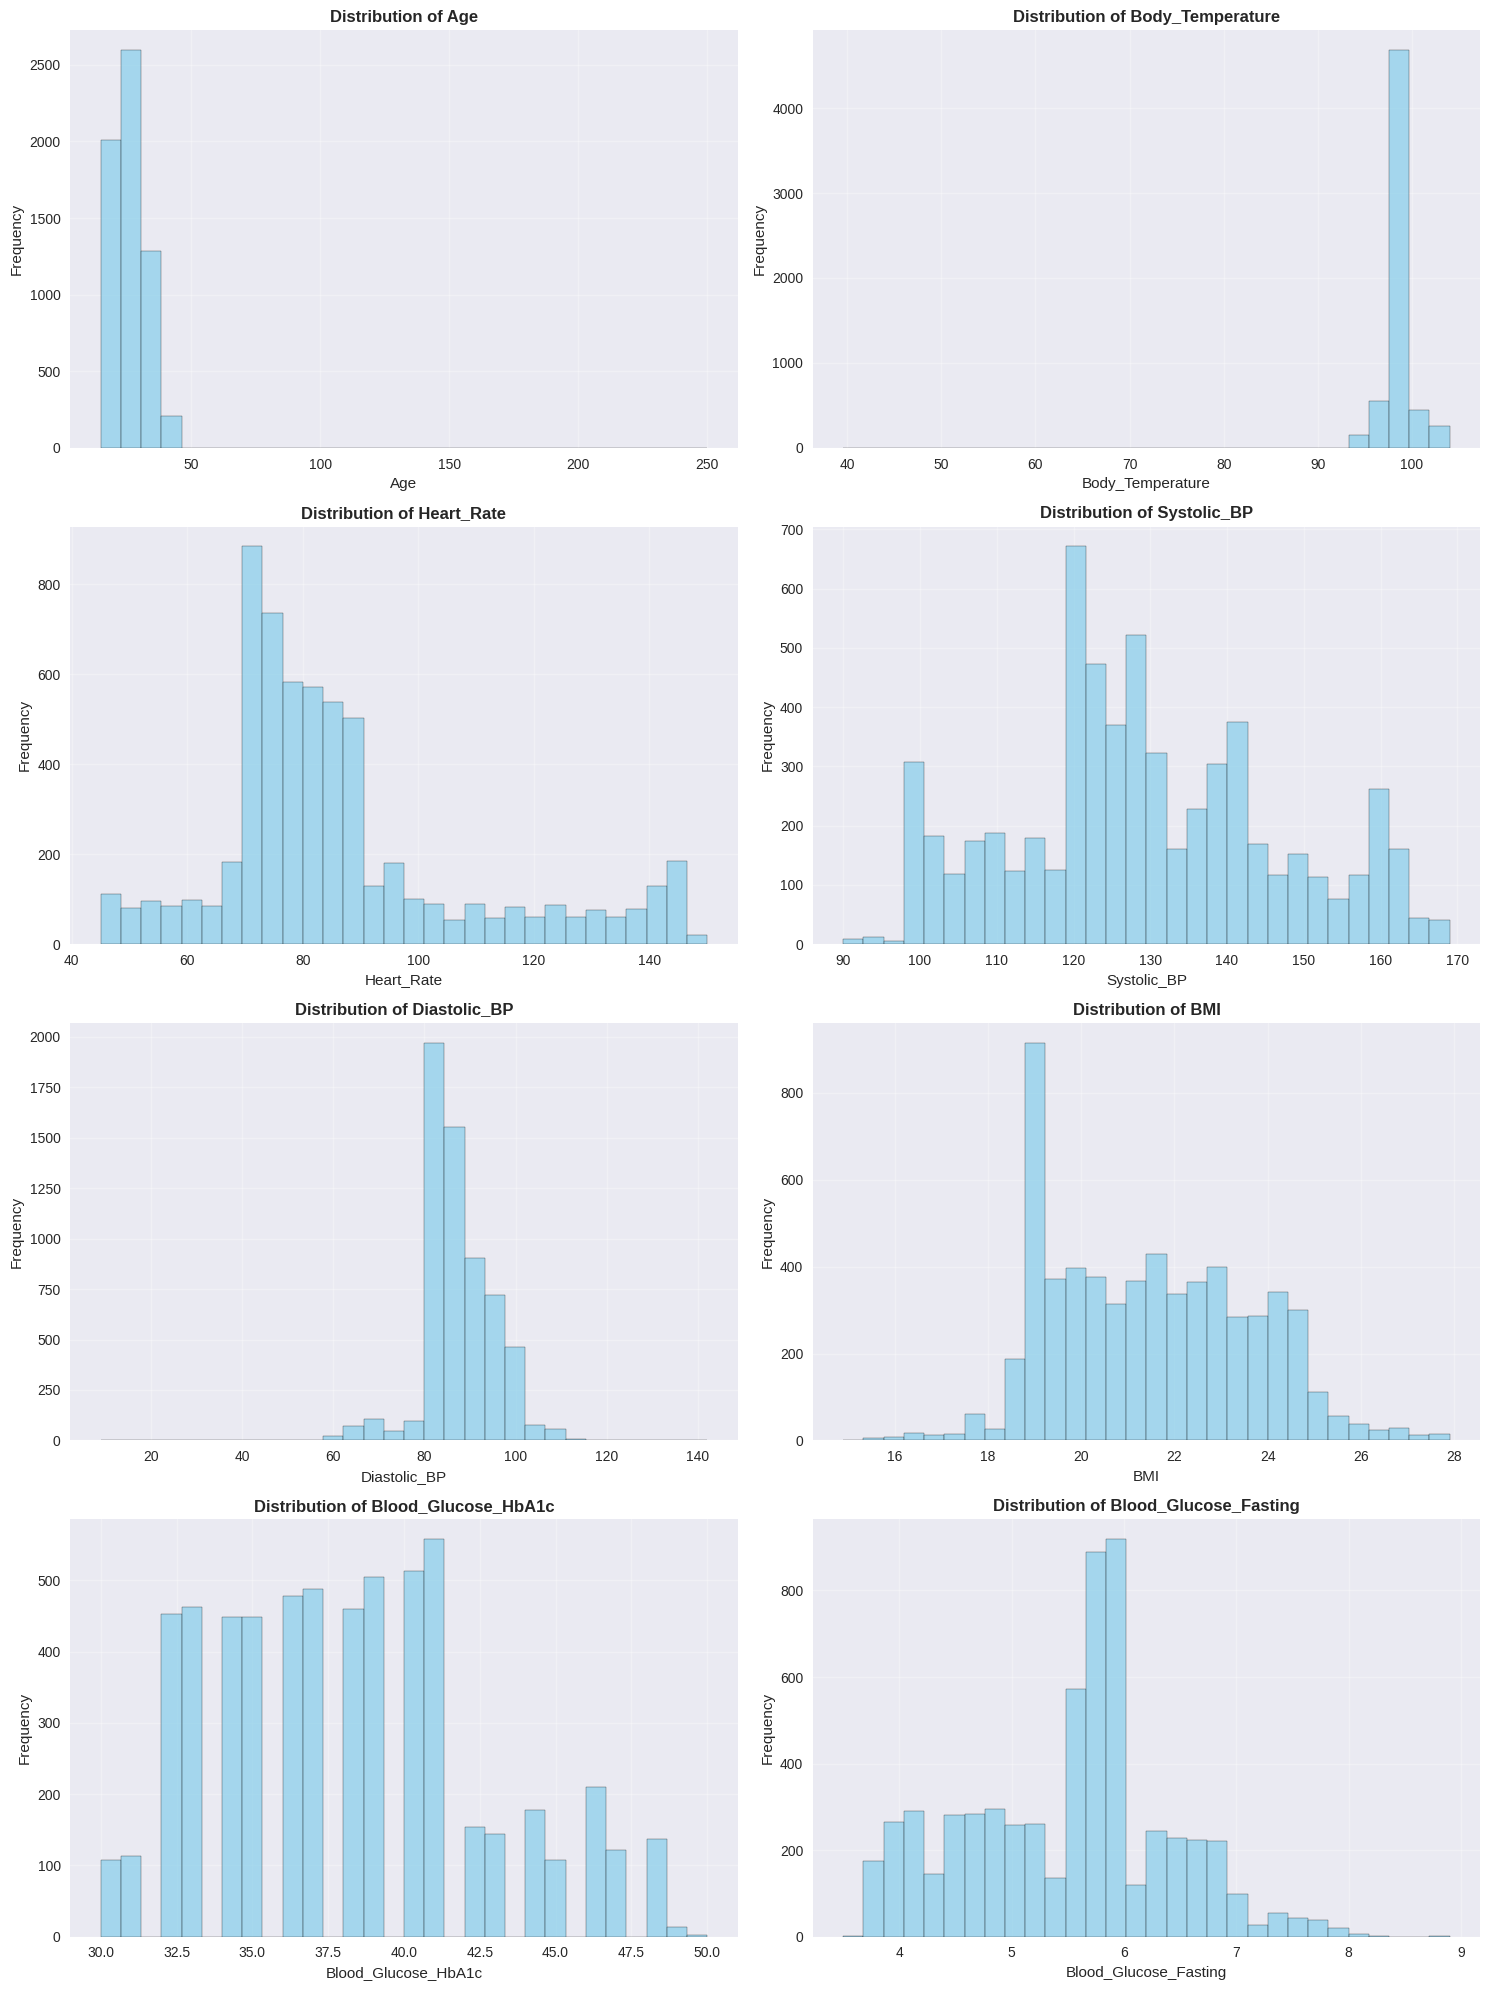

In [7]:
# Cell 7: Feature Distribution Analysis
# Visualization 2: Feature Distributions
numerical_features = ['Age', 'Body_Temperature', 'Heart_Rate', 'Systolic_BP',
                     'Diastolic_BP', 'BMI', 'Blood_Glucose_HbA1c', 'Blood_Glucose_Fasting']

fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.ravel()

for i, feature in enumerate(numerical_features):
    axes[i].hist(df_analysis[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

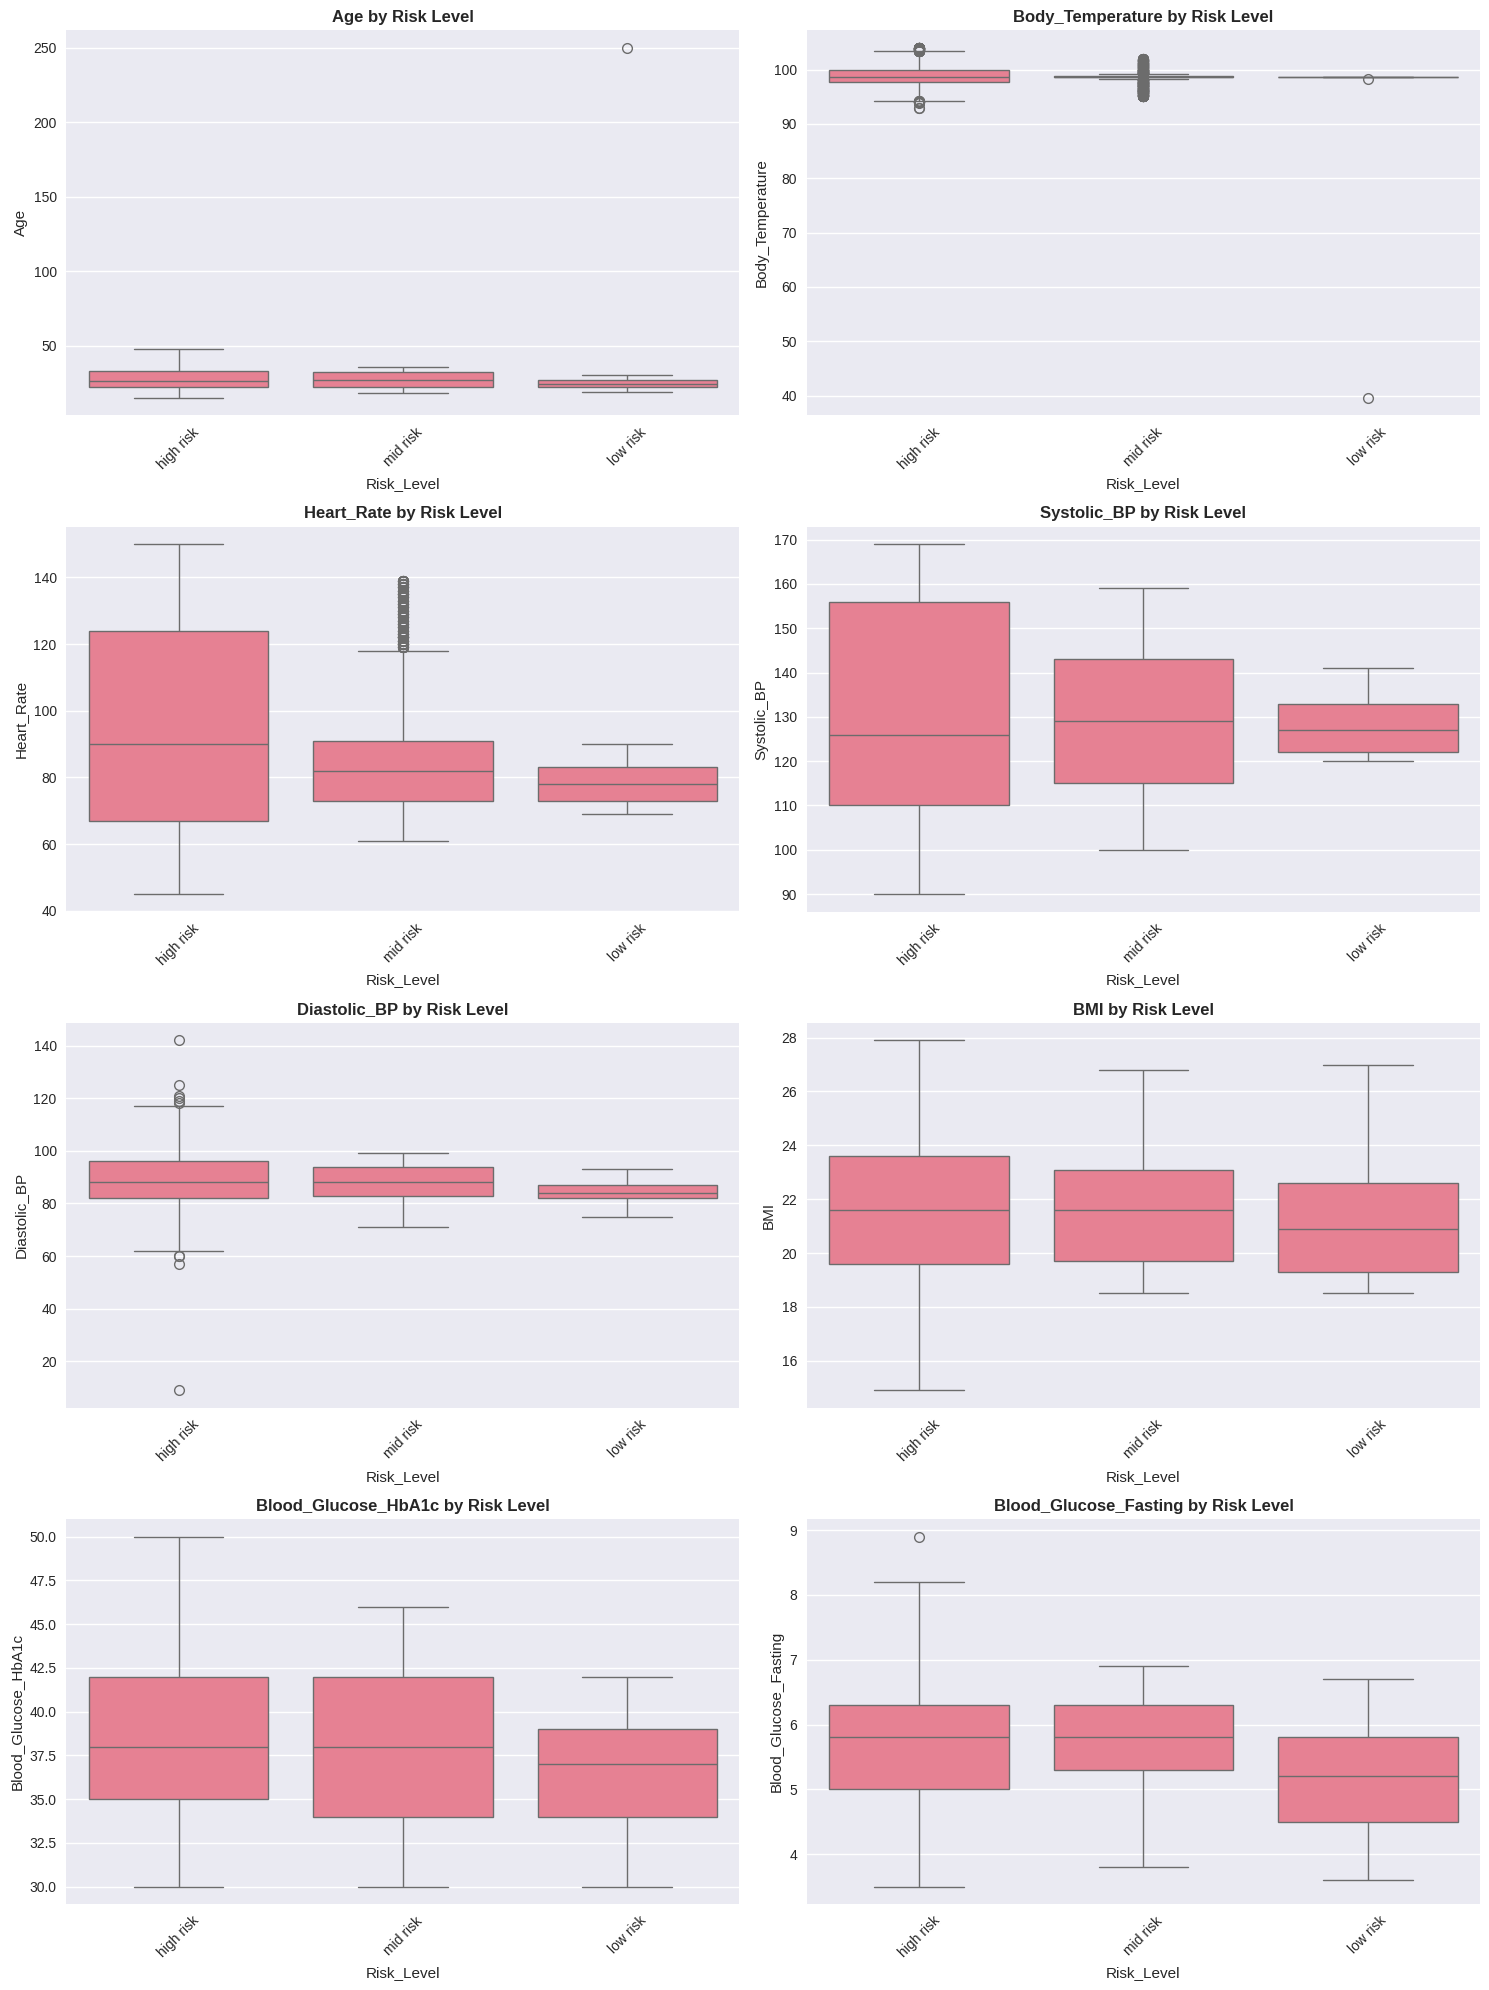

In [8]:
# Cell 8: Box Plots by Risk Level
# Visualization 3: Box plots showing feature distributions by risk level
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.ravel()

for i, feature in enumerate(numerical_features):
    sns.boxplot(data=df_analysis, x='Risk_Level', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} by Risk Level', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


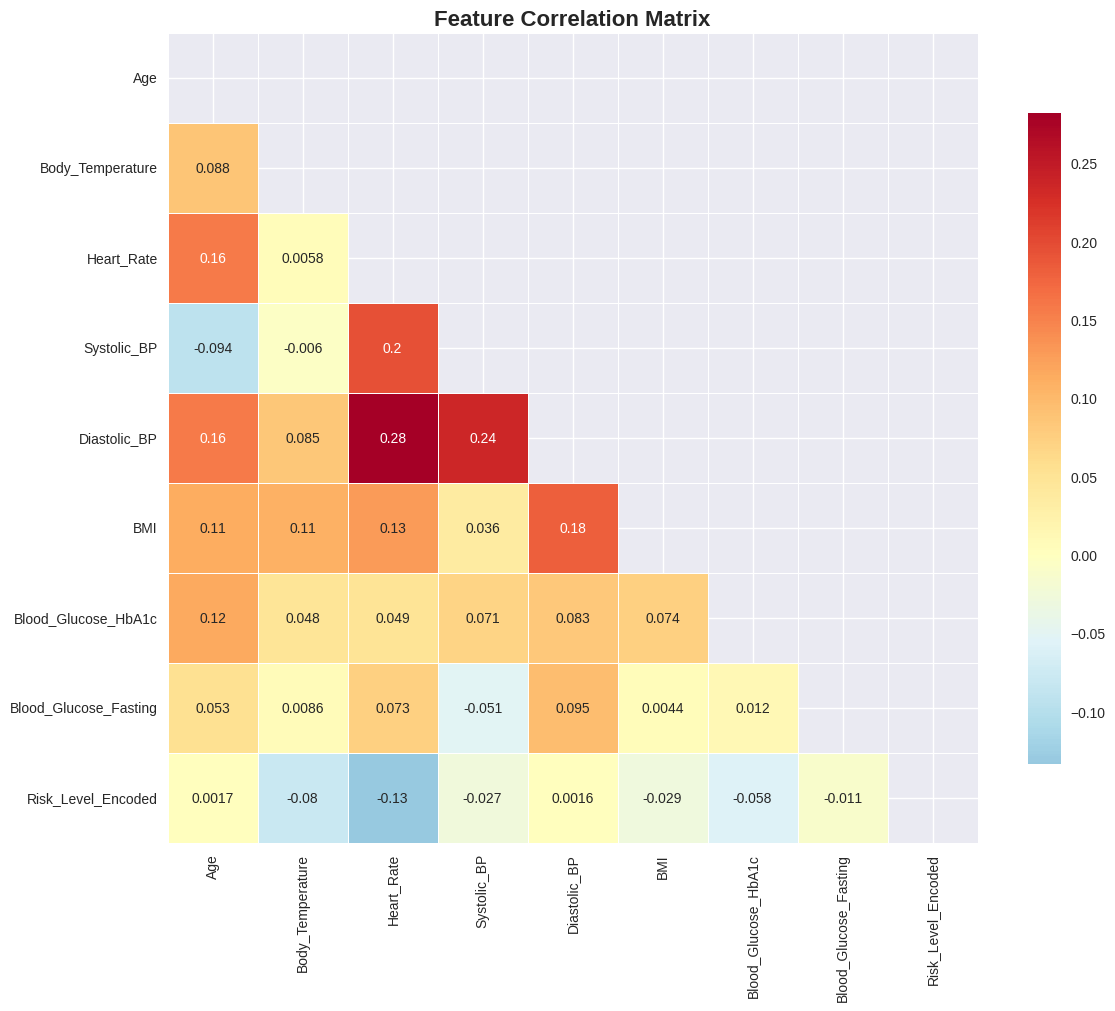

In [9]:



# Cell 9: Correlation Analysis
# Visualization 4: Correlation Heatmap
# First encode the target variable for correlation analysis
le = LabelEncoder()
df_corr = df_analysis.copy()
df_corr['Risk_Level_Encoded'] = le.fit_transform(df_corr['Risk_Level'])

# Calculate correlation matrix
correlation_matrix = df_corr.drop('Risk_Level', axis=1).corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": .8}, mask=mask)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


In [10]:
# Cell 10: Data Preprocessing for Machine Learning
# Prepare features and target
X = df_analysis.drop('Risk_Level', axis=1)
y = df_analysis['Risk_Level']

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print("Risk Level Encoding:")
for i, level in enumerate(le.classes_):
    print(f"{level}: {i}")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2,
                                                    random_state=42, stratify=y_encoded)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set shape: {X_train_scaled.shape}")
print(f"Test set shape: {X_test_scaled.shape}")

Risk Level Encoding:
high risk: 0
low risk: 1
mid risk: 2

Training set shape: (4882, 8)
Test set shape: (1221, 8)


In [11]:
# Cell 11: Machine Learning Model Training and Evaluation
# Define models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': xgb.XGBClassifier(random_state=42, eval_metric='mlogloss'),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# Train and evaluate models
results = {}
predictions = {}

for name, model in models.items():
    print(f"\n=== Training {name} ===")

    # Train model
    if name in ['K-Nearest Neighbors', 'Logistic Regression', 'Naive Bayes']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'predictions': y_pred,
        'probabilities': y_pred_proba,
        'model': model
    }

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))



=== Training Decision Tree ===
Accuracy: 0.8960
Classification Report:
              precision    recall  f1-score   support

   high risk       0.99      0.79      0.88       412
    low risk       0.87      1.00      0.93       400
    mid risk       0.85      0.90      0.87       409

    accuracy                           0.90      1221
   macro avg       0.90      0.90      0.90      1221
weighted avg       0.91      0.90      0.89      1221


=== Training Random Forest ===
Accuracy: 0.9918
Classification Report:
              precision    recall  f1-score   support

   high risk       1.00      0.99      0.99       412
    low risk       1.00      1.00      1.00       400
    mid risk       0.98      0.99      0.99       409

    accuracy                           0.99      1221
   macro avg       0.99      0.99      0.99      1221
weighted avg       0.99      0.99      0.99      1221


=== Training XGBoost ===
Accuracy: 0.9926
Classification Report:
              precision    r

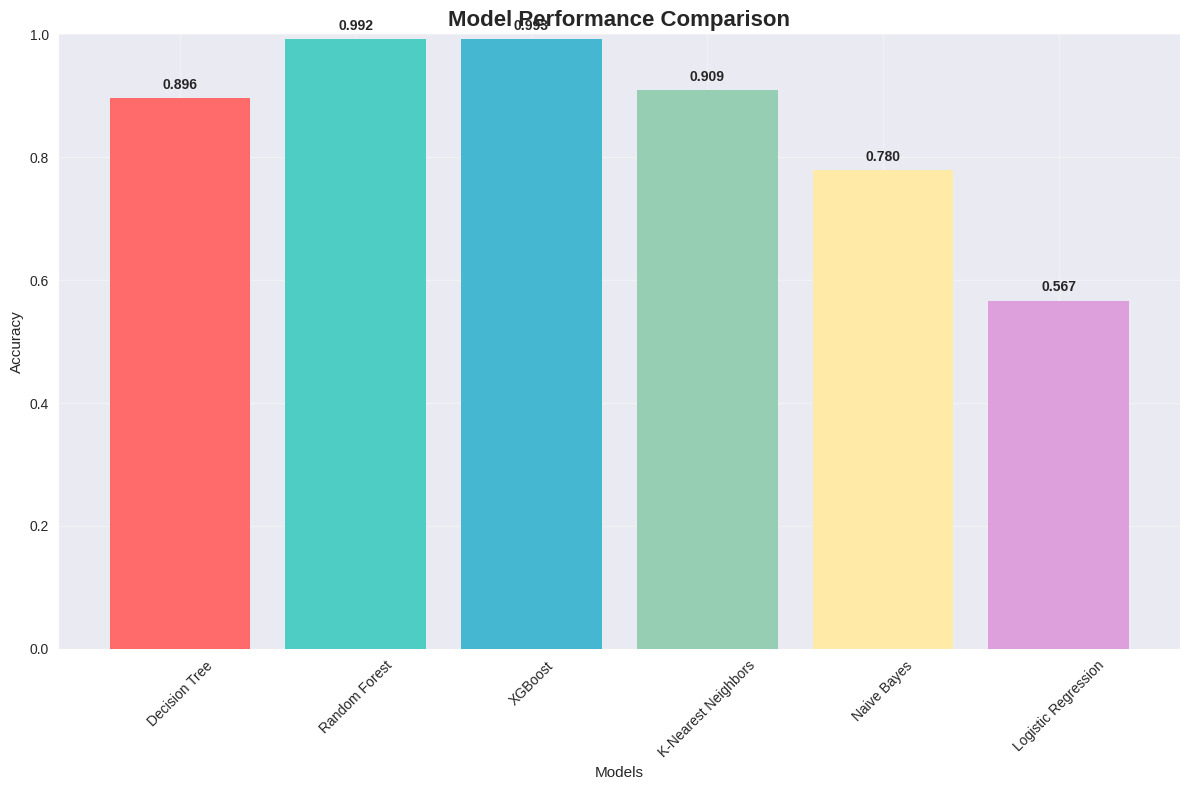

In [12]:
# Cell 12: Model Comparison Visualization
# Visualization 5: Model Performance Comparison
model_names = list(results.keys())
accuracies = [results[name]['accuracy'] for name in model_names]

plt.figure(figsize=(12, 8))
bars = plt.bar(model_names, accuracies, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD'])
plt.title('Model Performance Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Add value labels on bars
for bar, accuracy in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{accuracy:.3f}', ha='center', va='bottom', fontweight='bold')

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


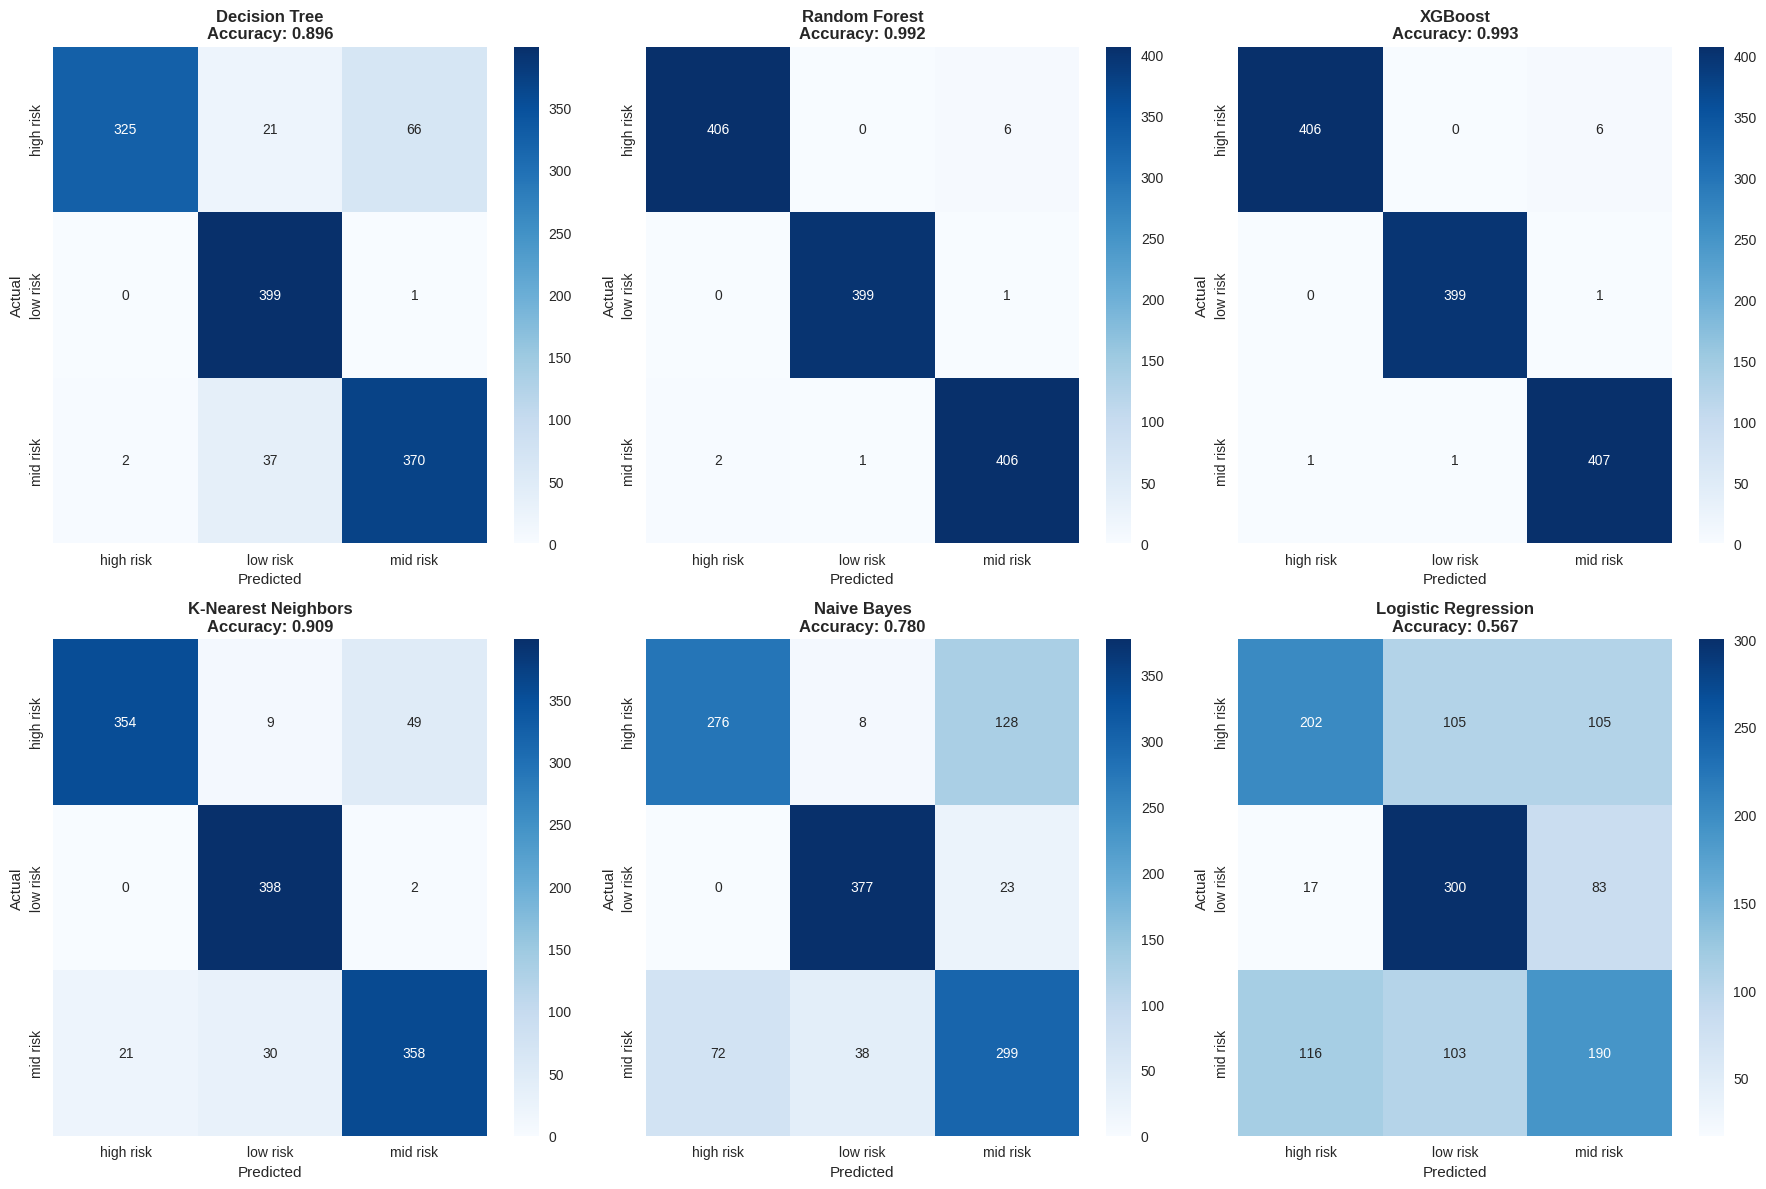

In [13]:
# Cell 13: Confusion Matrices
# Visualization 6: Confusion Matrices for all models
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (name, result) in enumerate(results.items()):
    cm = confusion_matrix(y_test, result['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_)
    axes[i].set_title(f'{name}\nAccuracy: {result["accuracy"]:.3f}', fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.tight_layout()
plt.show()


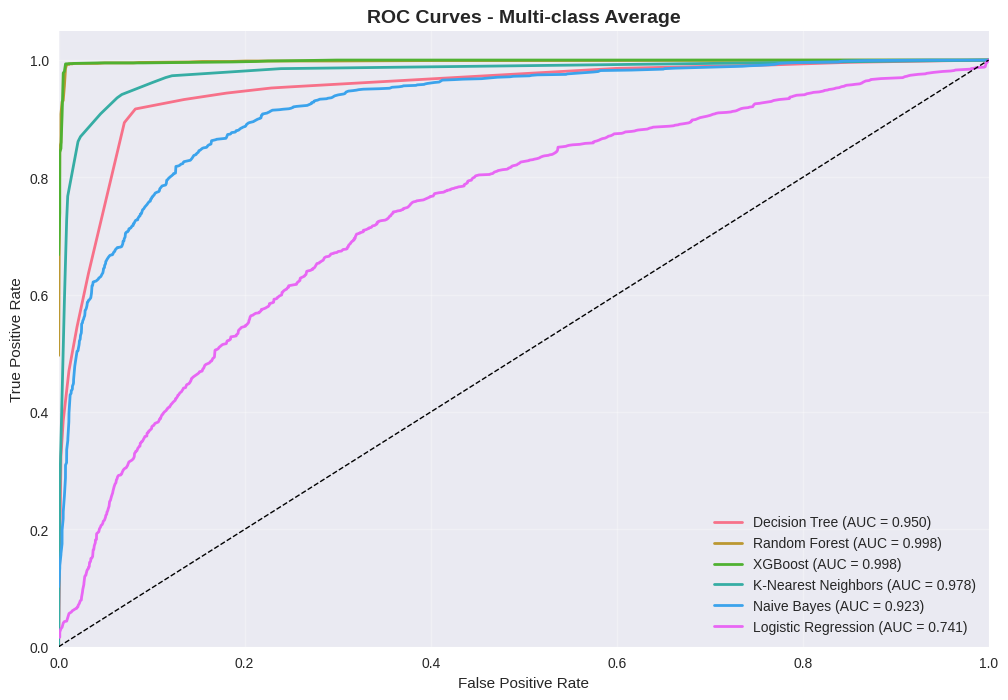

In [14]:
# Cell 14: ROC Curves
# Visualization 7: ROC Curves
plt.figure(figsize=(12, 8))

for name, result in results.items():
    # Calculate ROC curve for each class and average
    fpr = {}
    tpr = {}
    roc_auc = {}

    for i in range(len(le.classes_)):
        fpr[i], tpr[i], _ = roc_curve((y_test == i).astype(int),
                                     result['probabilities'][:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Calculate macro-average ROC curve
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(le.classes_))]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(len(le.classes_)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= len(le.classes_)
    macro_auc = auc(all_fpr, mean_tpr)

    plt.plot(all_fpr, mean_tpr, label=f'{name} (AUC = {macro_auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multi-class Average', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()


In [15]:
# Cell 15: Best Model Analysis (XGBoost)
# Get the best performing model
best_model_name = max(results.keys(), key=lambda k: results[k]['accuracy'])
best_model = results[best_model_name]['model']

print(f"Best Model: {best_model_name}")
print(f"Best Accuracy: {results[best_model_name]['accuracy']:.4f}")

# Detailed classification report for best model
print("\n=== DETAILED CLASSIFICATION REPORT FOR BEST MODEL ===")
y_pred_best = results[best_model_name]['predictions']
print(classification_report(y_test, y_pred_best, target_names=le.classes_))


Best Model: XGBoost
Best Accuracy: 0.9926

=== DETAILED CLASSIFICATION REPORT FOR BEST MODEL ===
              precision    recall  f1-score   support

   high risk       1.00      0.99      0.99       412
    low risk       1.00      1.00      1.00       400
    mid risk       0.98      1.00      0.99       409

    accuracy                           0.99      1221
   macro avg       0.99      0.99      0.99      1221
weighted avg       0.99      0.99      0.99      1221



=== SHAP ANALYSIS ===


<Figure size 1000x800 with 0 Axes>

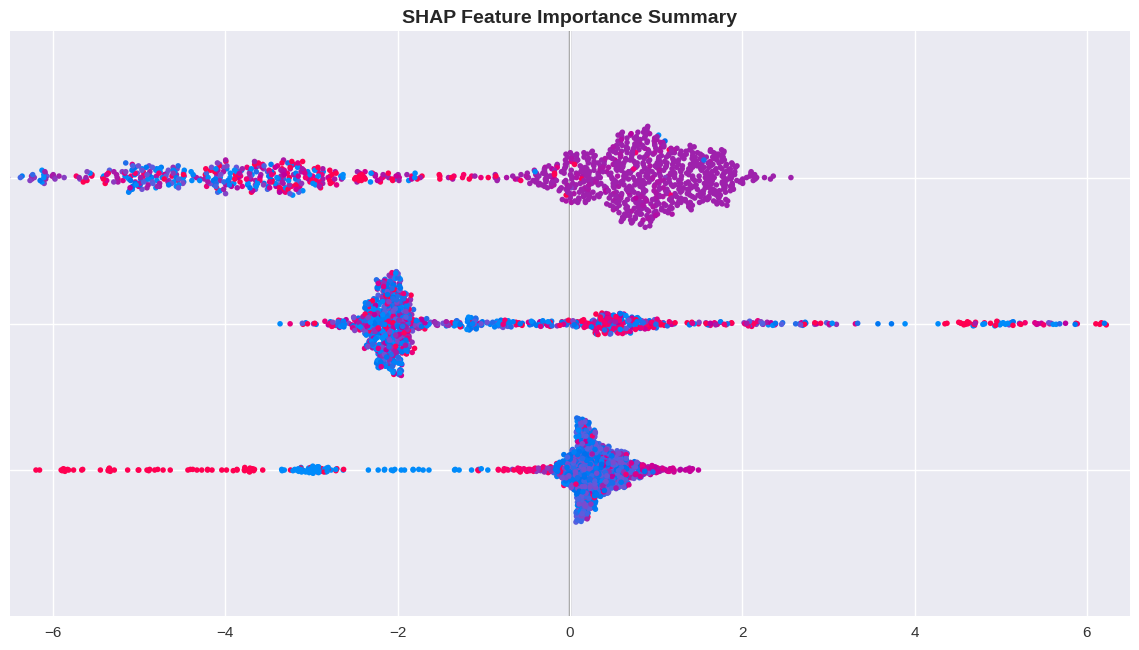

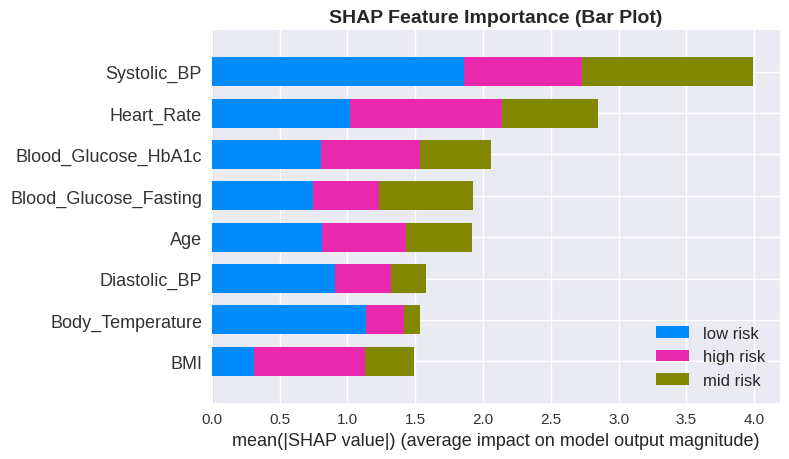

In [16]:

# Cell 16: SHAP Analysis for Model Interpretability
# Visualization 8: SHAP Feature Importance
print("=== SHAP ANALYSIS ===")

# Use the best model for SHAP analysis
if best_model_name == 'XGBoost':
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)
elif best_model_name in ['K-Nearest Neighbors', 'Logistic Regression', 'Naive Bayes']:
    explainer = shap.Explainer(best_model, X_train_scaled)
    shap_values = explainer(X_test_scaled)
else:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot
plt.figure(figsize=(10, 8))
if best_model_name == 'XGBoost':
    shap.summary_plot(shap_values, X_test, feature_names=X.columns,
                     class_names=le.classes_, show=False)
else:
    shap.summary_plot(shap_values.values, X_test_scaled, feature_names=X.columns,
                     show=False)
plt.title('SHAP Feature Importance Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# SHAP Bar Plot
plt.figure(figsize=(10, 6))
if best_model_name == 'XGBoost':
    shap.summary_plot(shap_values, X_test, feature_names=X.columns,
                     plot_type="bar", class_names=le.classes_, show=False)
else:
    shap.summary_plot(shap_values.values, X_test_scaled, feature_names=X.columns,
                     plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


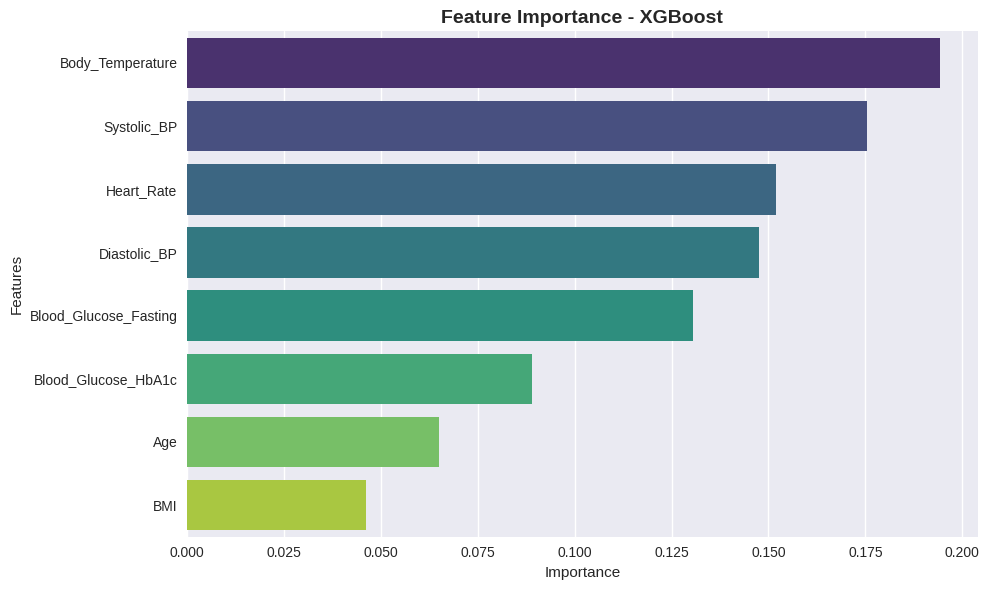

=== FEATURE IMPORTANCE RANKING ===


,feature,importance
1,Body_Temperature,0.194264
3,Systolic_BP,0.175371
2,Heart_Rate,0.151964
4,Diastolic_BP,0.147560
7,Blood_Glucose_Fasting,0.130610
6,Blood_Glucose_HbA1c,0.088944
0,Age,0.065036
5,BMI,0.046250


In [17]:
# Cell 17: Feature Importance Analysis
# Visualization 9: Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

    print("=== FEATURE IMPORTANCE RANKING ===")
    display(feature_importance)

=== CROSS-VALIDATION ANALYSIS ===
Decision Tree: 0.8832 (+/- 0.0263)
Random Forest: 0.9898 (+/- 0.0072)
XGBoost: 0.9904 (+/- 0.0050)
K-Nearest Neighbors: 0.9091 (+/- 0.0148)
Naive Bayes: 0.7751 (+/- 0.0879)
Logistic Regression: 0.5602 (+/- 0.0262)


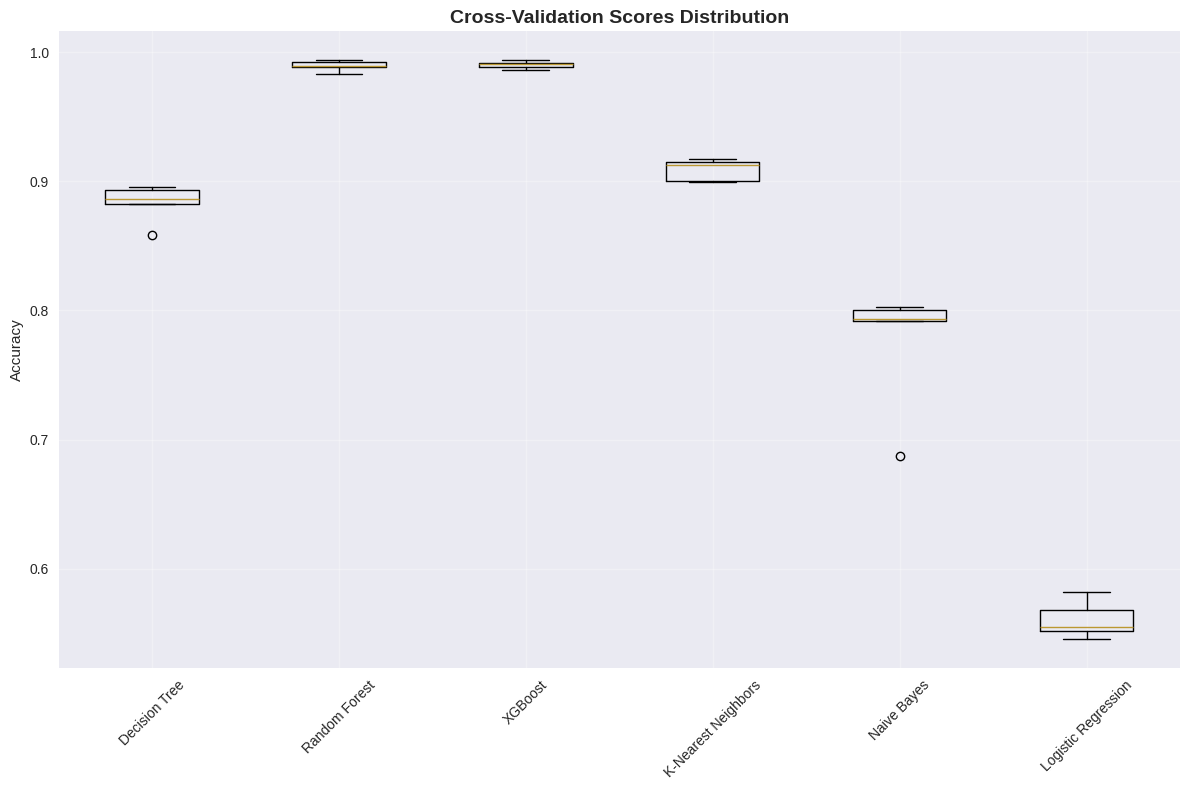

In [18]:
# Cell 18: Cross-Validation Analysis
# Perform k-fold cross-validation
print("=== CROSS-VALIDATION ANALYSIS ===")
cv_scores = {}
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    if name in ['K-Nearest Neighbors', 'Logistic Regression', 'Naive Bayes']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=kfold, scoring='accuracy')
    else:
        scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='accuracy')

    cv_scores[name] = scores
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

# Visualization 10: Cross-validation scores
plt.figure(figsize=(12, 8))
cv_data = [cv_scores[name] for name in model_names]
plt.boxplot(cv_data, labels=model_names)
plt.title('Cross-Validation Scores Distribution', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:





# Cell 19: Data Export for Paper Tables
# Create summary tables for the paper
print("=== CREATING SUMMARY TABLES FOR PAPER ===")

# Table 1: Dataset Summary
dataset_summary = pd.DataFrame({
    'Attribute': ['Total Samples', 'Features', 'Classes', 'High Risk', 'Mid Risk', 'Low Risk'],
    'Value': [len(df_analysis), len(X.columns), len(le.classes_),
              risk_counts['high risk'], risk_counts['mid risk'], risk_counts['low risk']],
    'Percentage': ['100%', '-', '-', f"{risk_percentages['high risk']:.1f}%",
                   f"{risk_percentages['mid risk']:.1f}%", f"{risk_percentages['low risk']:.1f}%"]
})

print("Dataset Summary Table:")
display(df)

=== CREATING SUMMARY TABLES FOR PAPER ===
Dataset Summary Table:


,Patient_ID,Name,Age,Body_Temperature,Heart_Rate,Systolic_BP,Diastolic_BP,BMI,Blood_Glucose_HbA1c,Blood_Glucose_Fasting,Risk_Level
0,101,Bhavana,20,97.5,91,161,100,24.9,41,5.8,high risk
1,102,Mithila,45,97.7,99,99,94,22.1,36,5.7,high risk
2,103,Phoolan,29,98.6,84,129,87,19.0,42,6.4,mid risk
3,104,Joyonti,26,99.5,135,161,101,23.7,46,4.5,high risk
4,105,Vana,38,102.5,51,106,91,18.8,38,4.3,high risk
...,...,...,...,...,...,...,...,...,...,...,...
6098,6199,Sonki,24,96.0,101,142,97,20.3,39,6.7,mid risk
6099,6200,Jayanarayani,38,96.0,59,129,94,20.0,39,7.0,high risk
6100,6201,Sarvika,40,103.3,145,123,95,24.6,36,5.0,high risk
6101,6202,Aardhana,21,99.0,130,152,99,23.2,47,6.6,high risk
